**PROJECT TEAM ID**: PTID-CDS-DEC-25-3516    

**PROJECT CODE** :PRCP-1020-HousePricePred
    
**PROJECT NAME** : House Price Prediction

# House Price Prediction
### PRCP-1020 Capstone Project

**Domain:** Real Estate / Property Price Prediction

**Objective:** The primary objective of this project is to build an accurate regression-based machine learning model to predict house sale prices using key property features.

##  1. Business Case



* This project helps predict the right price of a house so buyers and sellers can make better decisions.

**Objective:**

* Predict house sale prices using property features

* Identify key factors influencing house prices

* Support data-driven decisions for buyers and sellers

## 2. Domain Analysis
**Domain: Real Estate / Property Price Prediction

**Problem Type: Regression Problem
    
### Key factors influencing house prices:


    
* **SalePrice** - the property's sale price in dollars. This is the target variable that you're trying to predict.
* MSSubClass: The building class
* MSZoning: The general zoning classification
* LotFrontage: Linear feet of street connected to property
* LotArea: Lot size in square feet
* Street: Type of road access
* Alley: Type of alley access
* LotShape: General shape of property
* LandContour: Flatness of the property
* Utilities: Type of utilities available
* LotConfig: Lot configuration
* LandSlope: Slope of property
* Neighborhood: Physical locations within Ames city limits
* Condition1: Proximity to main road or railroad
* Condition2: Proximity to main road or railroad (if a second is present)
* BldgType: Type of dwelling
* HouseStyle: Style of dwelling
* OverallQual: Overall material and finish quality
* OverallCond: Overall condition rating
* YearBuilt: Original construction date
* YearRemodAdd: Remodel date
* RoofStyle: Type of roof
* RoofMatl: Roof material
* Exterior1st: Exterior covering on house
* Exterior2nd: Exterior covering on house (if more than one material)
* MasVnrType: Masonry veneer type
* MasVnrArea: Masonry veneer area in square feet
* ExterQual: Exterior material quality
* ExterCond: Present condition of the material on the exterior
* Foundation: Type of foundation
* BsmtQual: Height of the basement
* BsmtCond: General condition of the basement
* BsmtExposure: Walkout or garden level basement walls
* BsmtFinType1: Quality of basement finished area
* BsmtFinSF1: Type 1 finished square feet
* BsmtFinType2: Quality of second finished area (if present)
* BsmtFinSF2: Type 2 finished square feet
* BsmtUnfSF: Unfinished square feet of basement area
* TotalBsmtSF: Total square feet of basement area
* Heating: Type of heating
* HeatingQC: Heating quality and condition
* CentralAir: Central air conditioning
* Electrical: Electrical system
1stFlrSF: First Floor square feet
2ndFlrSF: Second floor square feet
* LowQualFinSF: Low quality finished square feet (all floors)
* GrLivArea: Above grade (ground) living area square feet
* smtFullBath: Basement full bathrooms
* smtHalfBath: Basement half bathrooms
* FullBath: Full bathrooms above grade
* HalfBath: Half baths above grade
* Bedroom: Number of bedrooms above basement level
* Kitchen: Number of kitchens
* KitchenQual: Kitchen quality
* TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
* Functional: Home functionality rating
* Fireplaces: Number of fireplaces
* FireplaceQu: Fireplace quality
* GarageType: Garage location
* GarageYrBlt: Year garage was built
* GarageFinish: Interior finish of the garage
* GarageCars: Size of garage in car capacity
* GarageArea: Size of garage in square feet
* GarageQual: Garage quality
* GarageCond: Garage condition
* PavedDrive: Paved driveway
* WoodDeckSF: Wood deck area in square feet
* penPorchSF: Open porch area in square feet
* EnclosedPorch: Enclosed porch area in square feet
* 3SsnPorch: Three season porch area in square feet
* ScreenPorch: Screen porch area in square feet
* PoolArea: Pool area in square feet
* PoolQC: Pool quality
* Fence: Fence quality
* MiscFeature: Miscellaneous feature not covered in other categories
* MiscVal: $Value of miscellaneous feature
* MoSold: Month Sold
* YrSold: Year Sold
* SaleType: Type of sale
* SaleCondition: Condition of sale



# Task 1: Data Analysis & EDA

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

**Load dataset**

In [ ]:
data= pd.read_csv("data.csv")


In [ ]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Basic Checks**

In [ ]:
data.shape

(1460, 81)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
data.duplicated().sum()  # no duplicate rows

np.int64(0)

**Cheak Missing values**

In [ ]:
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]


,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [ ]:
threshold = 0.4 * len(data)
cols_to_drop = data.columns[data.isnull().sum() > threshold]

print("Columns dropped (more than 40% missing):")
print(cols_to_drop)

data.drop(columns=cols_to_drop, inplace=True)

Columns dropped (more than 40% missing):
Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')


**Columns having more than 40% missing values were dropped because imputing such a large amount of missing data can introduce bias and noise, reducing model reliability.**

**Exploratory Data Analysis (EDA)**

**Target Variable Distribution**( **Visualize the SalePrice distribution)**

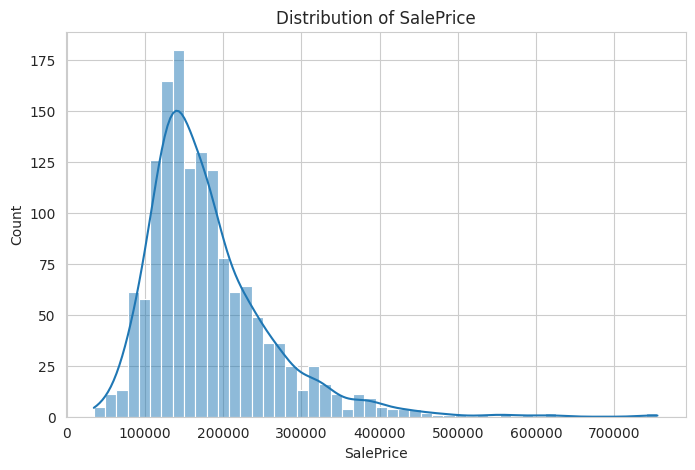

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['SalePrice'], bins=50, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

* SalePrice is right-skewed

**Price vs Living Area**

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

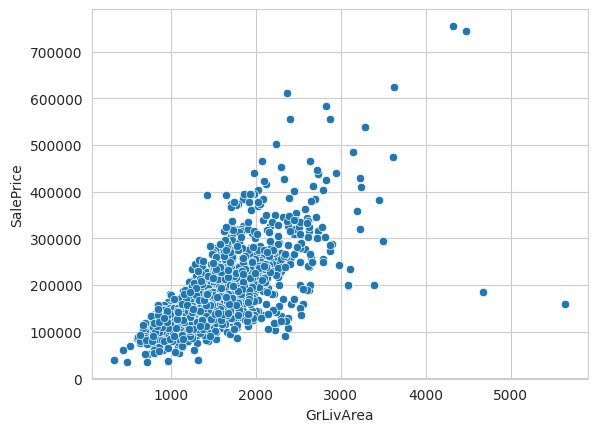

In [ ]:
sns.scatterplot(x=data['GrLivArea'], y=data['SalePrice'])


* Larger area → higher price

 * Some outliers present

**Price vs Neighborhood**

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

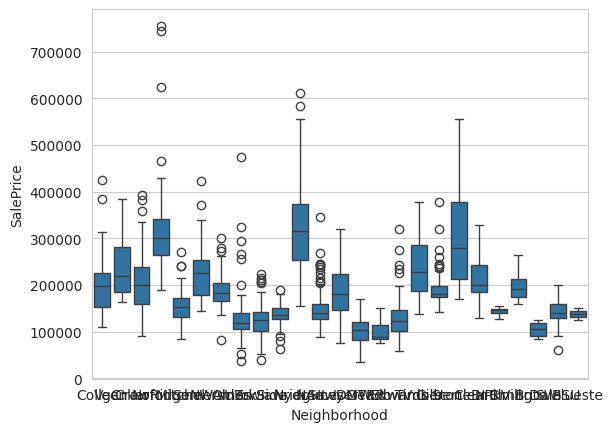

In [ ]:
sns.boxplot(x=data['Neighborhood'], y=data['SalePrice'])


* Location significantly impacts price

# Separate features and target


**Feature Engineering**

* Why Feature Engineering?

Raw features may not fully represent real-world meaning.

Created Features:

In [ ]:
# Create total square footage by combining basement and floor areas
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

It creates a new feature called TotalSF (Total Square Footage) by adding:

TotalBsmtSF → Basement area

1stFlrSF → First floor area

2ndFlrSF → Second floor area

 So, TotalSF represents the total usable area of the house.

In [ ]:
# Calculate house age at the time of sale
data['HouseAge'] = data['YrSold'] - data['YearBuilt']


It creates a new feature called HouseAge.

YrSold → year when the house was sold

YearBuilt → year when the house was constructed

 HouseAge = how old the house is at the time of sale

In [ ]:
# Calculate total bathrooms (full + half baths, weighted)
data['TotalBathrooms'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']


It creates a new feature called TotalBathrooms that represents the effective number of bathrooms in a house.

In [ ]:
# Drop unnecessary columns
data.drop(['Id', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1, inplace=True, errors='ignore')

In [ ]:
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,TotalBathrooms
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,2,2008,WD,Normal,208500,2566,5,3.5
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,5,2007,WD,Normal,181500,2524,31,2.5
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,9,2008,WD,Normal,223500,2706,7,3.5
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,2,2006,WD,Abnorml,140000,2473,91,2.0
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,12,2008,WD,Normal,250000,3343,8,3.5


**Handle Missing Values**

**Numerical → Median**

**Categorical → Mode**

**Numerical columns**

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64']).columns

In [ ]:
# Fill numeric missing values with median
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

**Categorical columns**

In [ ]:
cat_cols = data.select_dtypes(include=['object']).columns

In [ ]:
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]

,0


 Handle Outliers (IQR method)

In [ ]:
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower, upper)
    return df

num_features = num_cols.drop('SalePrice')
data = cap_outliers(data, num_features)

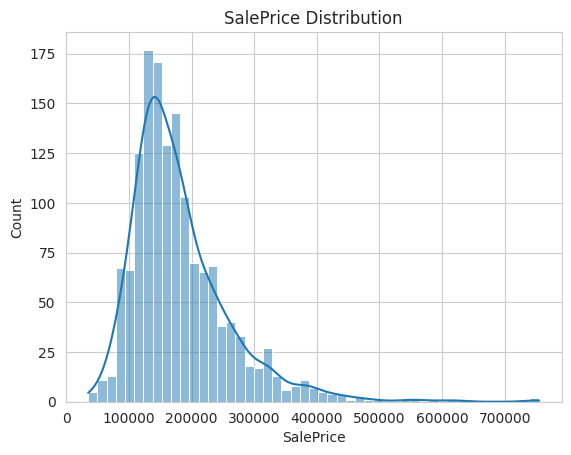

In [ ]:
sns.histplot(data['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()


**Check log-transformed SalePrice**

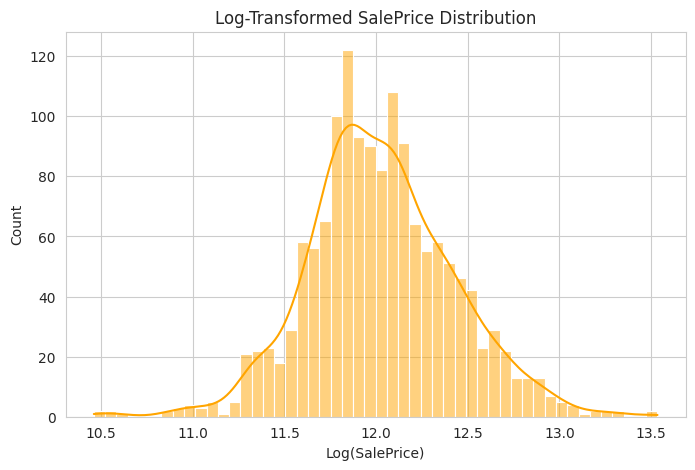

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(data['SalePrice']), bins=50, kde=True, color='orange')
plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Count")
plt.show()

**SalePrice is right-skewed, so we will apply a log transformation to make it more normally distributed. This helps linear models perform better.**

**Visualize correlations**

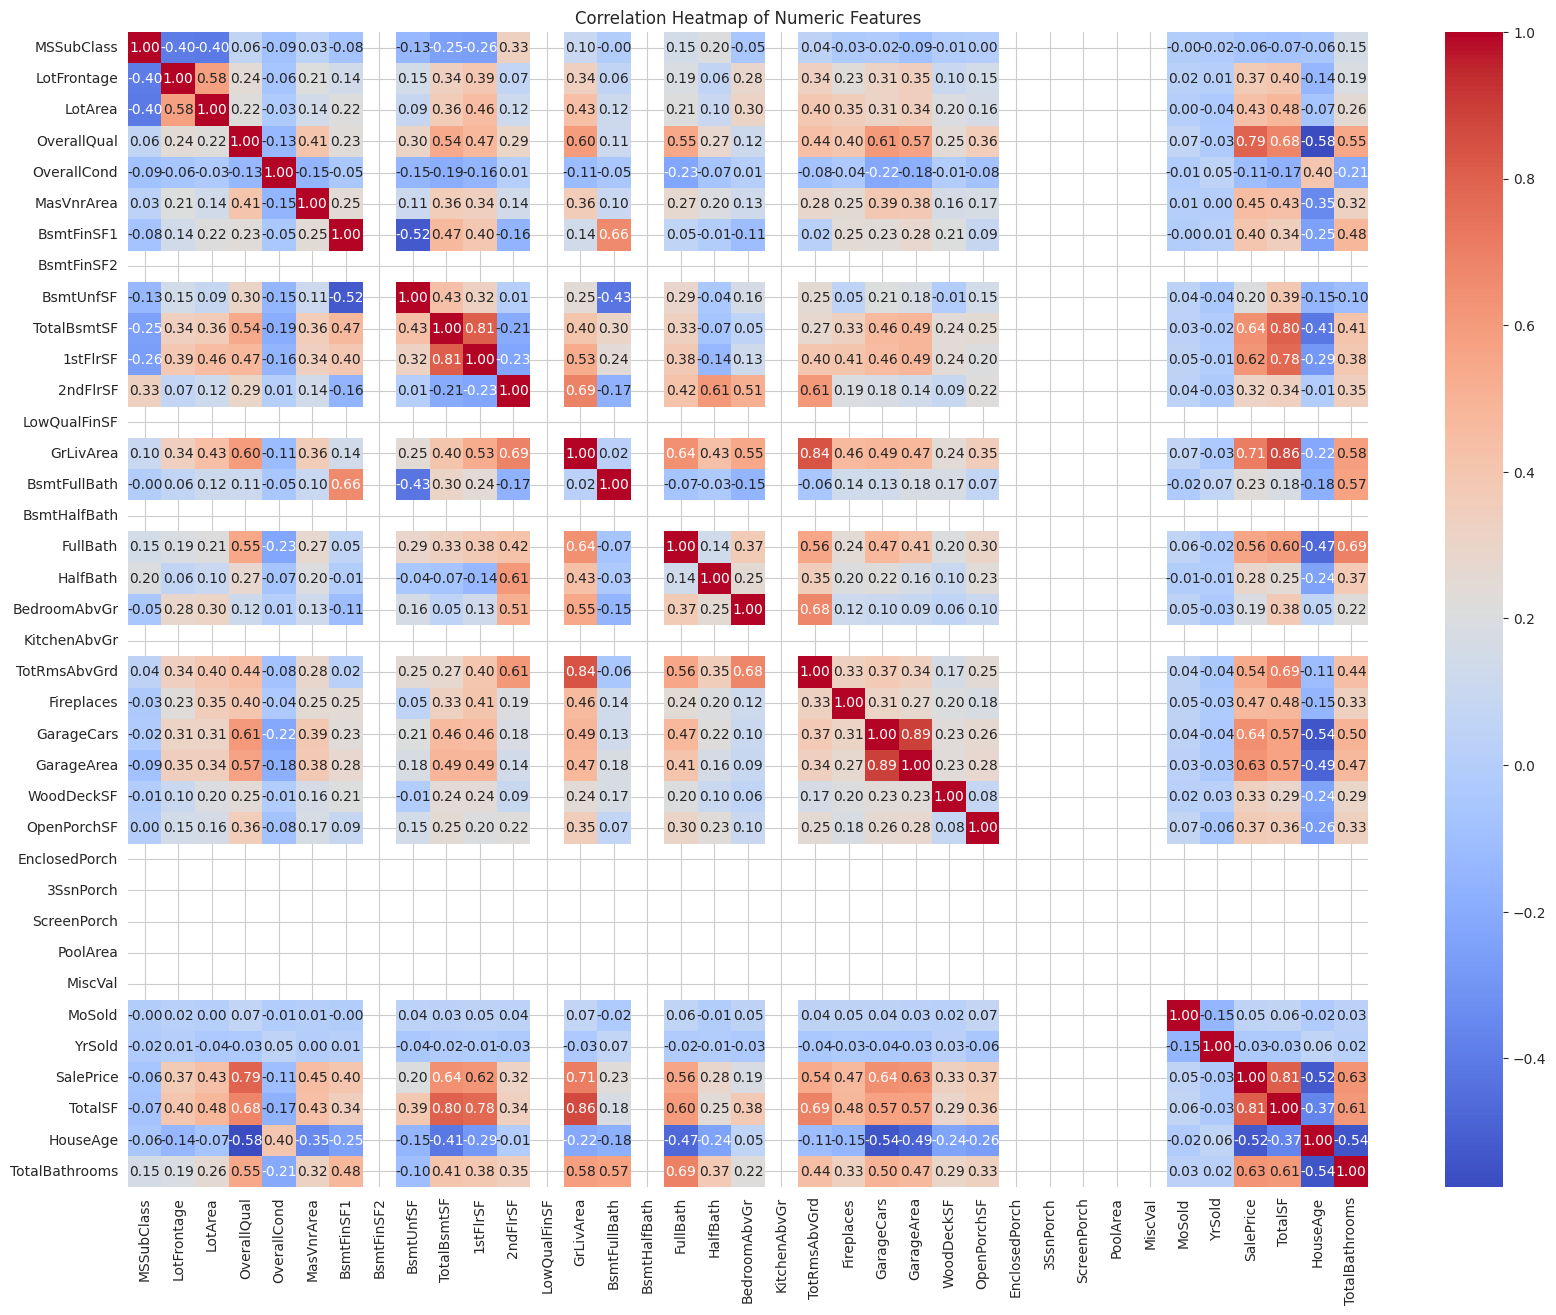

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,15))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


**computes the Pearson correlation between each numeric feature and SalePrice.**

In [ ]:
# Select numeric features
num_cols = data.select_dtypes(include=['int64','float64']).columns

# Calculate correlation with target
correlations = data[num_cols].corr()['SalePrice'].sort_values(ascending=False)

print(correlations)


SalePrice         1.000000
TotalSF           0.805518
OverallQual       0.791965
GrLivArea         0.708153
GarageCars        0.644002
TotalBsmtSF       0.636999
GarageArea        0.630138
TotalBathrooms    0.625618
1stFlrSF          0.620743
FullBath          0.560664
TotRmsAbvGrd      0.536067
Fireplaces        0.468700
MasVnrArea        0.448618
LotArea           0.432216
BsmtFinSF1        0.400330
LotFrontage       0.371542
OpenPorchSF       0.369024
WoodDeckSF        0.330378
2ndFlrSF          0.316547
HalfBath          0.284108
BsmtFullBath      0.227813
BsmtUnfSF         0.203278
BedroomAbvGr      0.185740
MoSold            0.046432
YrSold           -0.028923
MSSubClass       -0.063602
OverallCond      -0.106261
HouseAge         -0.524724
BsmtFinSF2             NaN
LowQualFinSF           NaN
BsmtHalfBath           NaN
KitchenAbvGr           NaN
EnclosedPorch          NaN
3SsnPorch              NaN
ScreenPorch            NaN
PoolArea               NaN
MiscVal                NaN
N

**OverallQual, TotalSF, GrLivArea → very strong positive correlation → highly predictive.**

 # **Data Preprocessing(pipeline)**

In [ ]:
# Separate features and target
X = data.drop('SalePrice', axis=1)
y = np.log1p(data['SalePrice'])  # log-transform target

In [ ]:
# Identify numeric features
num_features = X.select_dtypes(include=['int64','float64']).columns


In [ ]:
# Identify categorical features
cat_features = X.select_dtypes(include=['object']).columns

In [ ]:
# Define preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

Preprocessing ensures features are scaled and categorical variables are encoded for the model.

**Train-test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# **Model Building**

### **Linear Regression**

In [ ]:
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [ ]:
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression RMSE: 0.12986852363219195


In [ ]:
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.9096203628846937


### **Ridge Regression**

In [ ]:
# Ridge Regression with alpha = 10
from sklearn.linear_model import Ridge
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10))
])


In [ ]:
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

In [ ]:
print("Ridge Regression Results")
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2:", r2_score(y_test, ridge_pred))

Ridge Regression Results
RMSE: 0.1282291602654862
R2: 0.9118877314422081


## **Lasso Regression**

In [ ]:
# Lasso Regression with alpha = 0.0005
from sklearn.linear_model import Lasso
lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.0005, max_iter=5000))
])


In [ ]:
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

In [ ]:
print("Lasso Regression Results")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2:", r2_score(y_test, lasso_pred))

Lasso Regression Results
RMSE: 0.1265604015523354
R2: 0.9141661733738338


### **Gradient Boosting**

In [ ]:
gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.1, max_depth=4, random_state=42
    ))
])

In [ ]:
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [ ]:
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))

Gradient Boosting RMSE: 0.13642509988439092


In [ ]:
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))


Gradient Boosting R2: 0.9002641376095254


### **Random Forest Regression**

In [ ]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
rf_model = Pipeline([
    ('preprocessor', preprocessor),  # scaling & encoding
    ('model', RandomForestRegressor(
        n_estimators=200,   # number of trees
        max_depth=None,     # depth of trees
        random_state=42,    # reproducibility
        n_jobs=-1           # use all cores
    ))
])


In [ ]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression Results")
print("RMSE:", rmse)
print("R2:", r2)


Random Forest Regression Results
RMSE: 0.14311836009142406
R2: 0.8902376266792764


**Hyperparameter Tuning**

### **Ridge Regression**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_params = {'model__alpha': [0.1, 1, 10, 50, 100]}
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)
ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test)
print("Ridge Best Params:", ridge_grid.best_params_)
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge Best Params: {'model__alpha': 50}
Ridge RMSE: 0.13020884006938013
Ridge R2: 0.9091460681902739


### **Lasso Regression**

In [ ]:
lasso_params = {'model__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]}
lasso_grid = GridSearchCV(lasso_model, lasso_params, cv=5, scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train, y_train)
lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test)
print("Lasso Best Params:", lasso_grid.best_params_)
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("Lasso R2:", r2_score(y_test, lasso_pred))


Lasso Best Params: {'model__alpha': 0.001}
Lasso RMSE: 0.13295864211868222
Lasso R2: 0.9052681696415228


### **Gradient Boosting Regression**

In [ ]:
gb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5]
}
gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test)
print("Gradient Boosting Best Params:", gb_grid.best_params_)
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))


Gradient Boosting Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300}
Gradient Boosting RMSE: 0.13768564627965518
Gradient Boosting R2: 0.8984125354311497


### **Random Forest Regression**

In [ ]:
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf_model, rf_params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest Best Params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Random Forest RMSE: 0.14511463671250238
Random Forest R2: 0.8871542455917341


# **Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})
print("\nModel Comparison:")
print(results.sort_values(by='RMSE'))



Model Comparison:
               Model      RMSE  R2 Score
0  Linear Regression  0.129869  0.909620
1              Ridge  0.130209  0.909146
2              Lasso  0.132959  0.905268
4  Gradient Boosting  0.137686  0.898413
3      Random Forest  0.145115  0.887154


* After evaluating multiple machine learning models using RMSE and R² score, Linear Regression achieved the lowest RMSE (0.1298) and highest R² (0.9096).

* This indicates that the relationship between house features and price is largely linear, and the applied feature engineering and log transformation helped linear models perform exceptionally well.

* Therefore, Linear Regression is selected as the final model for house price prediction.

# **Save Model**

In [ ]:
import pickle

with open("house_price_model.pkl", "wb") as f:
    pickle.dump(lr, f)

print("Model saved successfully")


Model saved successfully


# **Customer Suggestions for Buying a House**

### **Focus on Quality and Size**

* Look for houses with high OverallQual (material and finish quality).

* Prefer properties with large TotalSF (total square footage including basement and floors) for better investment value and comfort.

### **Choose the Right Neighborhood**

* Target neighborhoods with historically high SalePrice as they tend to retain or increase their value over time.

* Analyze trends in the Neighborhood feature for price stability and growth potential.

### **Consider House Age**

* Choose newer houses (low HouseAge) for reduced maintenance costs and long-term durability.

* Older houses may require renovations, impacting budget and resale value.

### **Family-Friendly Features**

* Ensure the house has adequate TotalBathrooms for convenience.

* Check GrLivArea (above-ground living area) to meet space requirements for family members.

### **Budget Planning**

* Use the model’s log-transformed SalePrice predictions to estimate realistic pricing.

* Compare predicted prices with actual budget to make informed decisions.

* Consider both upfront cost and potential appreciation.

### **Investment Perspective**

* Houses with high quality, sufficient space, and located in good neighborhoods often provide better resale value.

* Prioritize features that match lifestyle needs while maximizing investment potential.

# Report on Challenges faced

### Challenges Faced and Solutions

#### 1. Missing Values

* Many features in the dataset, both numerical and categorical, had missing values.

* Solution: Numerical columns were filled with the median, and categorical columns were filled with the most frequent value (mode).

* Columns having more than 40% missing values were dropped because imputing such a large amount of missing data can introduce bias and noise, reducing model reliability.

#### 2. Outliers

* Some features, like GrLivArea and SalePrice, had extreme values that could negatively impact model performance.

* Solution: Outliers were capped using the Interquartile Range (IQR) method to reduce their effect.

#### 3.Categorical Variables with Many Levels

* Several categorical features had a large number of unique categories, making them difficult for models to interpret.

* Solution: OneHotEncoder was used to convert categorical variables into a format suitable for machine learning models.

#### 4. Right-Skewed Target Variable

* The SalePrice variable was highly right-skewed, which can affect the accuracy of linear models.

* Solution: A log transformation was applied to stabilize variance and improve model predictions.

#### 5. Model Selection

* Choosing the most accurate predictive model was challenging due to multiple options.

* Solution: Multiple models, including Linear Regression, Ridge, Lasso, Random Forest, and Gradient Boosting, were trained and evaluated using RMSE and R² scores.

#### 6. Hyperparameter Tuning

* Optimizing model parameters to achieve the best performance required careful experimentation.

* Solution: GridSearchCV was used to find the optimal parameters such as alpha, n_estimators, learning_rate, and max_depth.